In [3]:
from google.colab import files
uploaded = files.upload()

Saving customer_feedback.csv to customer_feedback (1).csv


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


========== DATASET LOADED SUCCESSFULLY ==========
Shape: (100, 2)

Columns: ['review', 'sentiment']

First 5 rows:
                                              review sentiment
0  The service was excellent and the team was ver...  positive
1        I am very happy with the support I received  positive
2  The product quality is amazing and delivery wa...  positive
3       Customer service solved my issue immediately  positive
4         Very satisfied with the overall experience  positive

========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     100 non-null    object
 1   sentiment  100 non-null    object
dtypes: object(2)
memory usage: 1.7+ KB
None

========== MISSING VALUES ==========
review       0
sentiment    0
dtype: int64

========== SENTIMENT COUNTS ==========
sentiment
positive    50
negative    50
Name: 

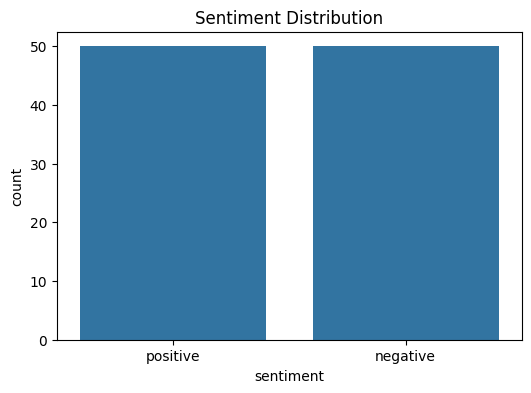

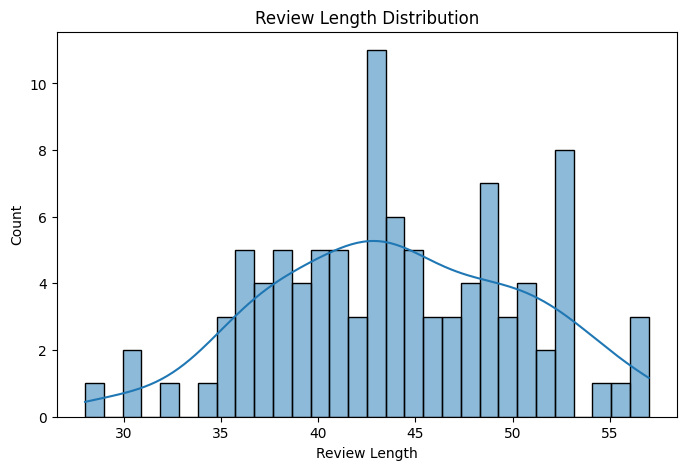

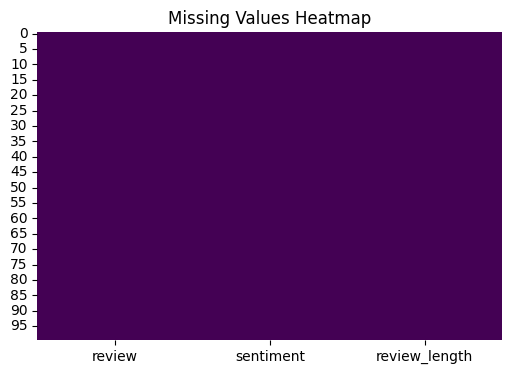


========== CLEANED DATA SAMPLE ==========
                                              review  \
0  The service was excellent and the team was ver...   
1        I am very happy with the support I received   
2  The product quality is amazing and delivery wa...   
3       Customer service solved my issue immediately   
4         Very satisfied with the overall experience   

                                clean_review  
0             service excellent team helpful  
1                     happy support received  
2     product quality amazing delivery quick  
3  customer service solved issue immediately  
4               satisfied overall experience  

========== ENCODED SENTIMENT COUNTS ==========
sentiment
1    50
0    50
Name: count, dtype: int64

Training samples: 80
Testing samples: 20

TF-IDF Shapes:
X_train_tfidf: (80, 151)
X_test_tfidf: (20, 151)

========== LOGISTIC REGRESSION RESULTS ==========
Accuracy: 0.6

Classification Report:

              precision    recall  f1-sco

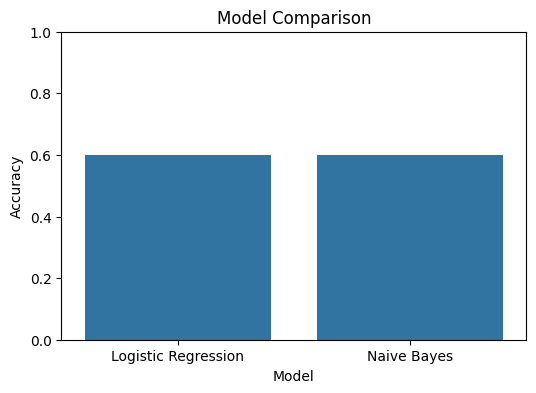


========== BEST MODEL ==========
Best Model: Logistic Regression


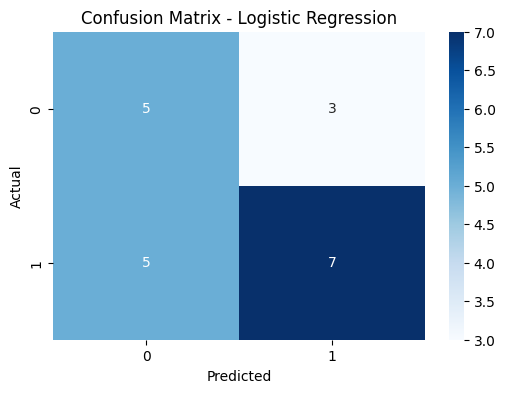


========== SAMPLE PREDICTION ==========
Sample Review: The service was excellent and I am very happy with the support
Prediction: Positive Review

========== FILES SAVED ==========
sentiment_model.pkl saved
tfidf_vectorizer.pkl saved

========== BUSINESS INSIGHTS ==========
Total Reviews: 100
Positive Reviews: 50
Negative Reviews: 50
- Negative feedback is higher, indicating dissatisfaction.
- The business should improve support, delivery, or product quality.

========== PROJECT COMPLETED SUCCESSFULLY ==========


In [4]:
# =========================
# CLIENT FEEDBACK SENTIMENT ANALYZER
# FINAL PROJECT - SINGLE CELL CODE
# =========================

# 1) Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import pickle
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2) Download stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# 3) Load Dataset
df = pd.read_csv('customer_feedback.csv')

print("========== DATASET LOADED SUCCESSFULLY ==========")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

# 4) Basic Info
print("\n========== DATASET INFO ==========")
print(df.info())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== SENTIMENT COUNTS ==========")
print(df['sentiment'].value_counts())

# 5) EDA - Sentiment Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution')
plt.show()

# 6) Review Length Feature
df['review_length'] = df['review'].astype(str).apply(len)

# 7) EDA - Review Length Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['review_length'], bins=30, kde=True)
plt.title('Review Length Distribution')
plt.xlabel('Review Length')
plt.show()

# 8) Missing Values Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

# 9) Text Cleaning Function
def clean_text(text):
    text = str(text).lower()  # lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # remove links
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = text.strip()

    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

# 10) Apply Cleaning
df['clean_review'] = df['review'].apply(clean_text)

print("\n========== CLEANED DATA SAMPLE ==========")
print(df[['review', 'clean_review']].head())

# 11) Encode Sentiment Labels
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("\n========== ENCODED SENTIMENT COUNTS ==========")
print(df['sentiment'].value_counts())

# 12) Define Features and Target
X = df['clean_review']
y = df['sentiment']

# 13) Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# 14) TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF Shapes:")
print("X_train_tfidf:", X_train_tfidf.shape)
print("X_test_tfidf:", X_test_tfidf.shape)

# =========================
# MODEL 1: LOGISTIC REGRESSION
# =========================
lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, lr_pred)

print("\n========== LOGISTIC REGRESSION RESULTS ==========")
print("Accuracy:", lr_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

# =========================
# MODEL 2: MULTINOMIAL NAIVE BAYES
# =========================
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)
nb_acc = accuracy_score(y_test, nb_pred)

print("\n========== NAIVE BAYES RESULTS ==========")
print("Accuracy:", nb_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred))

# =========================
# MODEL COMPARISON
# =========================
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [lr_acc, nb_acc]
})

print("\n========== MODEL COMPARISON ==========")
print(comparison)

plt.figure(figsize=(6,4))
sns.barplot(x='Model', y='Accuracy', data=comparison)
plt.title('Model Comparison')
plt.ylim(0, 1)
plt.show()

# =========================
# BEST MODEL SELECTION
# =========================
if lr_acc >= nb_acc:
    best_model = lr_model
    best_model_name = "Logistic Regression"
    best_pred = lr_pred
else:
    best_model = nb_model
    best_model_name = "Naive Bayes"
    best_pred = nb_pred

print("\n========== BEST MODEL ==========")
print("Best Model:", best_model_name)

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# =========================
# CUSTOM REVIEW TEST
# =========================
sample_review = ["The service was excellent and I am very happy with the support"]
sample_clean = [clean_text(sample_review[0])]
sample_vector = tfidf.transform(sample_clean)
prediction = best_model.predict(sample_vector)

print("\n========== SAMPLE PREDICTION ==========")
print("Sample Review:", sample_review[0])
if prediction[0] == 1:
    print("Prediction: Positive Review")
else:
    print("Prediction: Negative Review")

# =========================
# SAVE MODEL + VECTORIZER
# =========================
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("\n========== FILES SAVED ==========")
print("sentiment_model.pkl saved")
print("tfidf_vectorizer.pkl saved")

# =========================
# BUSINESS INSIGHTS
# =========================
positive_count = (df['sentiment'] == 1).sum()
negative_count = (df['sentiment'] == 0).sum()
total = len(df)

print("\n========== BUSINESS INSIGHTS ==========")
print("Total Reviews:", total)
print("Positive Reviews:", positive_count)
print("Negative Reviews:", negative_count)

if positive_count > negative_count:
    print("- Overall customer feedback is mostly positive.")
    print("- Customers appear generally satisfied with the service/product.")
    print("- The company should maintain service quality and customer support standards.")
else:
    print("- Negative feedback is higher, indicating dissatisfaction.")
    print("- The business should improve support, delivery, or product quality.")

print("\n========== PROJECT COMPLETED SUCCESSFULLY ==========")

In [6]:
app_code = """
import streamlit as st
import pickle
import re
import string
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

with open('sentiment_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\\S+|www\\S+|https\\S+', '', text)
    text = re.sub(r'\\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

st.set_page_config(page_title="Client Feedback Sentiment Analyzer", layout="centered")

st.title("Client Feedback Sentiment Analyzer")
st.write("Enter client feedback below to predict whether it is Positive or Negative.")

user_input = st.text_area("Enter Feedback:")

if st.button("Analyze Sentiment"):
    if user_input.strip() == "":
        st.warning("Please enter some feedback text.")
    else:
        cleaned = clean_text(user_input)
        vectorized = tfidf.transform([cleaned])
        prediction = model.predict(vectorized)

        if prediction[0] == 1:
            st.success("Predicted Sentiment: Positive")
        else:
            st.error("Predicted Sentiment: Negative")
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py file created successfully!")

app.py file created successfully!
